# Crop Recommendation System: Distance Metrics, KNN, and K-Means++ Search Optimization

**Group:** Numpy
**Contributors:** Thanh Le, Dang Tran
**Problem type:** Top-$K$ recommendation / ranking

## Objective

Given soil and weather features, return a ranked list of the **Top-$K$ most suitable crops**.

- **Input features:** Nitrogen, phosphorus, potassium, temperature, humidity, pH, and rainfall.
- **Output:** ranked list of Top-$K$ crop labels.
- **Models compared:**
  1. **KNN baseline:** searches the entire training set.
  2. **KNN + K-Means++ search optimizer:** searches only samples in the nearest clusters, whose centroids act as search representatives.
- **Distance functions:** Euclidean, Manhattan, and Cosine distance.
- **Evaluation:** Precision@$K$, Recall@$K$, MAP@$K$, Hit Rate@$K$, and NDCG@$K$, plus inference latency and candidate-set reduction.
- An **appendix** also benchmarks the same distance functions on a classic single-label KNN / KNN++ classification setup (accuracy, precision, recall, F1 across many values of $K$), and documents the earlier sklearn-based search-index design that motivated the final K-Means++ optimizer above.

> **Important evaluation note:** This dataset provides one ground-truth crop label per row. Therefore, Recall@$K$ and Hit Rate@$K$ are numerically identical. Both are reported because they are commonly requested recommendation metrics, but their interpretation is discussed explicitly below.

**Dataset:** [Crop Recommendation Dataset on Kaggle](https://www.kaggle.com/datasets/aksahaha/crop-recommendation)

## 1. Environment and reproducibility

In [3]:
!pip install -q kagglehub pandas


[notice] A new release of pip is available: 23.2.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, silhouette_score

# Resolve project root robustly whether run from root or notebooks/main
current_dir = Path.cwd()
if (current_dir / 'src').exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / 'src').exists():
    PROJECT_ROOT = current_dir.parent
elif (current_dir.parent.parent / 'src').exists():
    PROJECT_ROOT = current_dir.parent.parent
else:
    PROJECT_ROOT = current_dir

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Import modular components built in src/
from config import (
    DISTANCE_METRICS,
    RANDOM_STATE,
    TARGET_COLUMN,
    TOP_K,
)
from data.loader import load_crop_dataset, infer_feature_columns
from data.split import split_train_val_test
from data.preprocessing import (
    fit_preprocessor,
    transform_features,
    transform_query_features,
    recommend_from_raw_features as recommend_from_raw_features_src
)
from models.base_knn import CropKNNRecommender
from models.kmeanSearch_knn import KMeansSearchKNNRecommender
from evaluation.metrics import ranking_metrics_at_k
from evaluation.evaluate import evaluate_recommender
from evaluation.tuning import benchmark_baseline_models, benchmark_hybrid_models

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Crop_recommendation.csv"
FEATURE_COLUMNS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]


## 2. Load and clean the dataset

The dataset is downloaded directly from Kaggle with `kagglehub`, so this notebook runs end-to-end in any fresh Colab session without needing to mount Google Drive or manually upload a file. All-empty columns are removed automatically, and feature names are standardized to lowercase so later cells are independent of the capitalization used in the source file.

In [4]:
import kagglehub
import shutil
import glob
import os


dataset_path = kagglehub.dataset_download("aksahaha/crop-recommendation")
print("Dataset downloaded to:")
print(dataset_path)


csv_file = glob.glob(os.path.join(dataset_path, "*.csv"))[0]
DATA_PATH = Path("/content/Crop_recommendation.csv")
shutil.copy(csv_file, DATA_PATH)
print("Copied to:", DATA_PATH)

Dataset downloaded to:
C:\Users\admin\.cache\kagglehub\datasets\aksahaha\crop-recommendation\versions\1


FileNotFoundError: [Errno 2] No such file or directory: '\\content\\Crop_recommendation.csv'

In [ ]:

df = load_crop_dataset(DATA_PATH)
FEATURE_COLUMNS = infer_feature_columns(df, target_column=TARGET_COLUMN)

print("Shape:", df.shape)
print("Target column:", TARGET_COLUMN)
print("Feature columns:", FEATURE_COLUMNS)
display(df.head())


Loaded: /content/Crop_recommendation.csv
Original shape: (2200, 10)
Removed all-empty columns: ['unnamed: 8', 'unnamed: 9']
Clean shape: (2200, 8)
Features (7): ['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph', 'rainfall']
Crop classes: 22


,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


## 3. Dataset analysis

This section examines data types, missing values, class balance, numerical ranges, distributions, outliers, correlations, and class-level feature profiles.

In [ ]:
summary_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
})

display(summary_table)
display(df[FEATURE_COLUMNS].describe().T.round(3))

,dtype,missing,missing_pct,unique_values
nitrogen,int64,0,0.0,137
phosphorus,int64,0,0.0,117
potassium,int64,0,0.0,73
temperature,float64,0,0.0,2200
humidity,float64,0,0.0,2200
ph,float64,0,0.0,2200
rainfall,float64,0,0.0,2200
label,object,0,0.0,22


,count,mean,std,min,25%,50%,75%,max
nitrogen,2200.0,50.552,36.917,0.000,21.000,37.000,84.250,140.000
phosphorus,2200.0,53.363,32.986,5.000,28.000,51.000,68.000,145.000
potassium,2200.0,48.149,50.648,5.000,20.000,32.000,49.000,205.000
temperature,2200.0,25.616,5.064,8.826,22.769,25.599,28.562,43.675
humidity,2200.0,71.482,22.264,14.258,60.262,80.473,89.949,99.982
ph,2200.0,6.469,0.774,3.505,5.972,6.425,6.924,9.935
rainfall,2200.0,103.464,54.958,20.211,64.552,94.868,124.268,298.560


**Remarks:**
- **Significant scale differences:** for instance, `ph` only ranges from about 3.5 to 9.9, while `rainfall` spans from about 20 to 300. Distance metrics must therefore be computed on scaled features to avoid one feature dominating the calculation.

In [ ]:
class_counts = df[TARGET_COLUMN].value_counts().sort_index()
print("Class counts:")
display(class_counts.to_frame("samples"))



Class counts:


,samples
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


**Remark: perfect label balance.** The dataset contains exactly 100 samples for each of the 22 crop types, so stratified splitting will give every crop a similar representation in train, validation, and test sets.

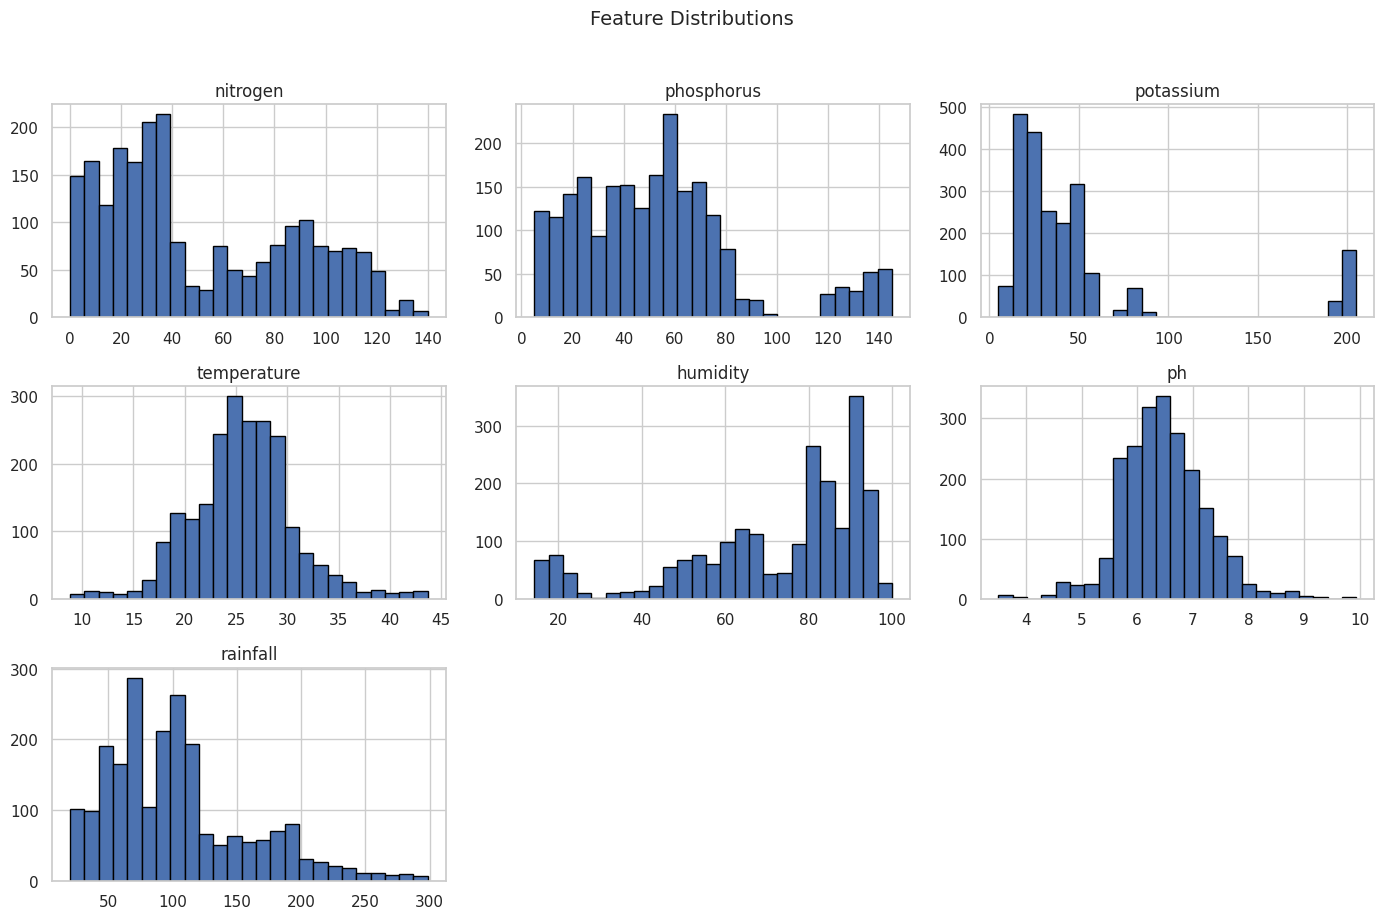

In [ ]:
df[FEATURE_COLUMNS].hist(figsize=(14, 9), bins=25, edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:**

- `Phosphorus` and `potassium` have right-skewed distributions, heavily concentrated at lower values (0-50) but stretching to extreme maximums of 145 and 205 respectively. This shows that only a few specific crops demand high doses of these minerals.
- `Rainfall` is right-skewed and unevenly distributed, heavily clustered around 50mm to 100mm. This shows that most crops thrive on low-to-moderate water levels, whereas a few outliers require heavy flooding.
- `Humidity` is left-skewed, with data densely clustered at the higher end (80% to 100%) and a maximum of 99.98%, reflecting that most crops evaluated are tropical and depend on highly humid environments.
- `Temperature` and `pH` show symmetrical, bell-shaped distributions. This demonstrates that the majority of crops share a similar, narrow comfort zone for temperature (around 25 degrees C) and soil pH (around 6.5).

**Remark:** the extreme maximums in skewed features (e.g. potassium reaching 205, rainfall reaching ~298.6) can easily dominate and mislead distance calculations if features are not scaled first.

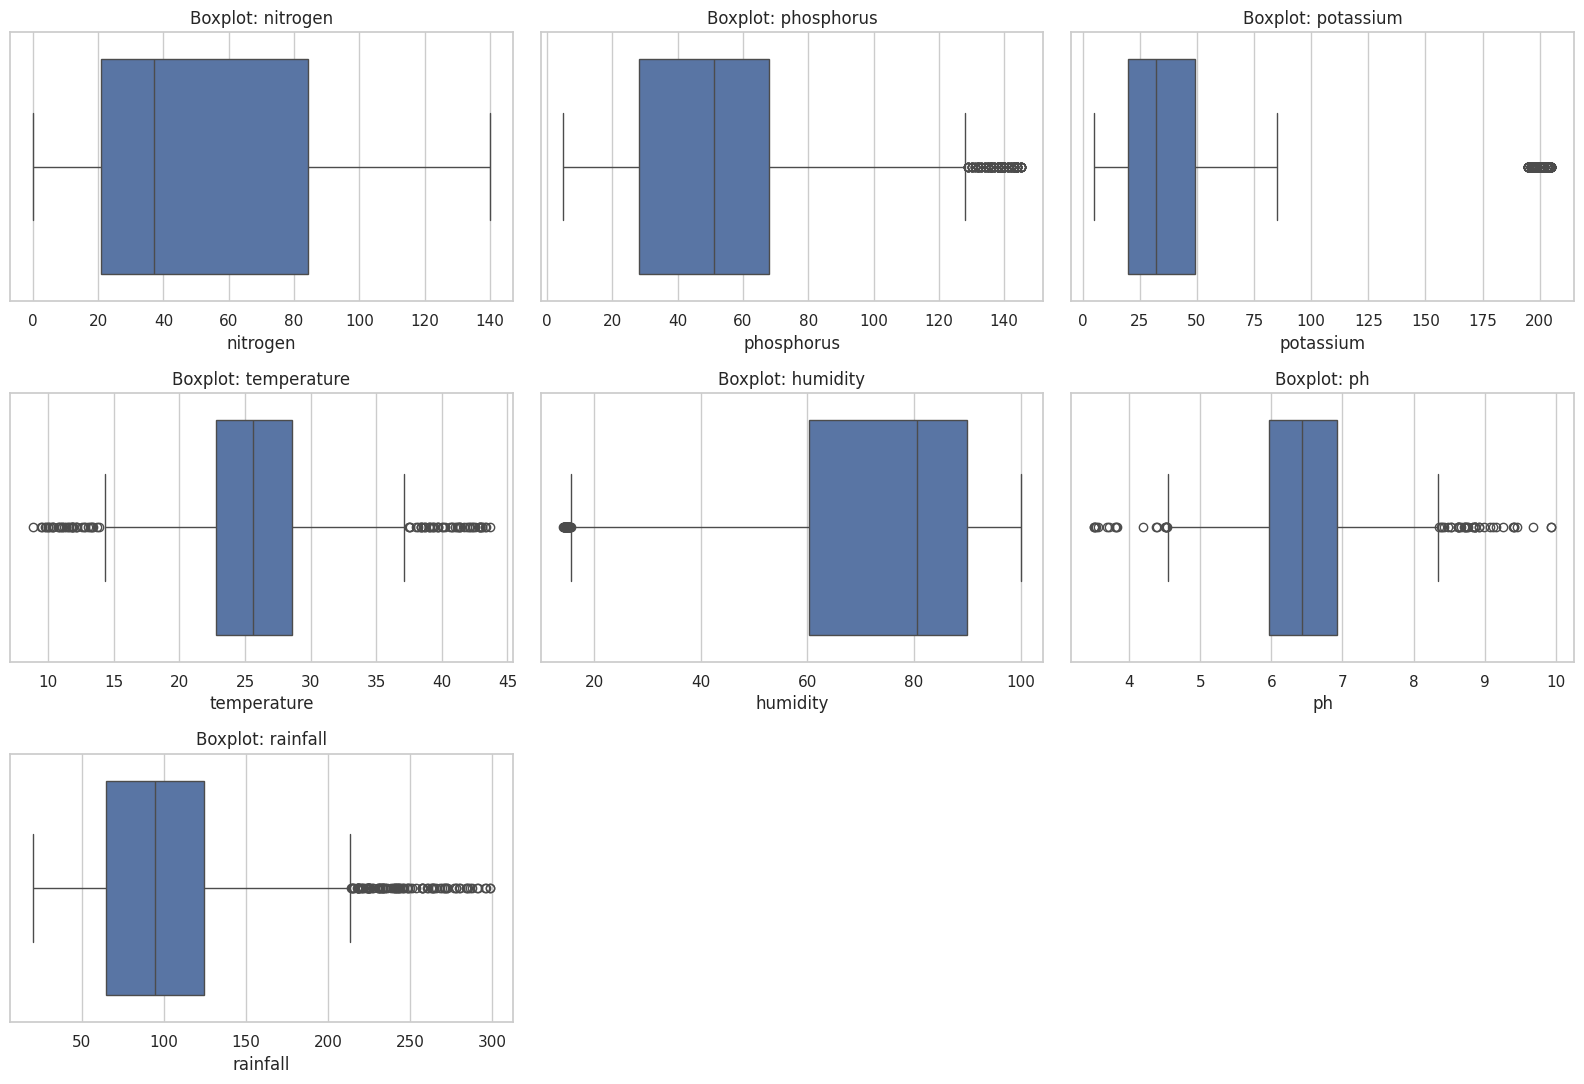

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURE_COLUMNS):
    sns.boxplot(x=df[feature], ax=ax)
    ax.set_title(f"Boxplot: {feature}")

for ax in axes[len(FEATURE_COLUMNS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

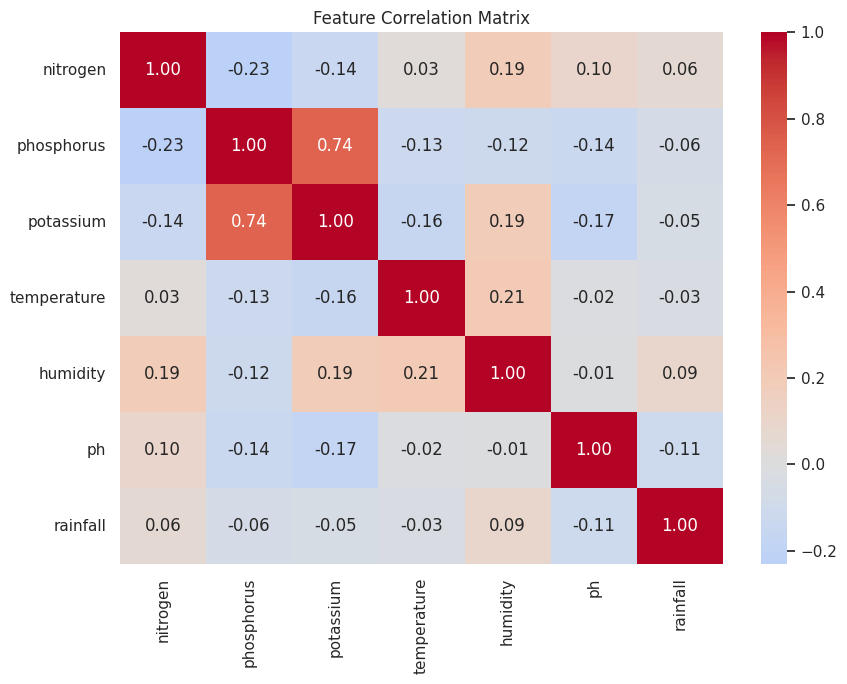

In [ ]:
plt.figure(figsize=(9, 7))
corr = df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Per-crop feature profiles

The charts below break features down by crop: average feature value per crop (sorted), and the full distribution of each feature per crop (boxplots). These views complement the correlation matrix above by showing which crops rely on which nutrients/conditions.

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.63,92.33,5.93,112.65
banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63
blackgram,40.02,67.47,19.24,29.97,65.12,7.13,67.88
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
coconut,21.98,16.93,30.59,27.41,94.84,5.98,175.69
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07
cotton,117.77,46.24,19.56,23.99,79.84,6.91,80.40
grapes,23.18,132.53,200.11,23.85,81.88,6.03,69.61
jute,78.40,46.86,39.99,24.96,79.64,6.73,174.79


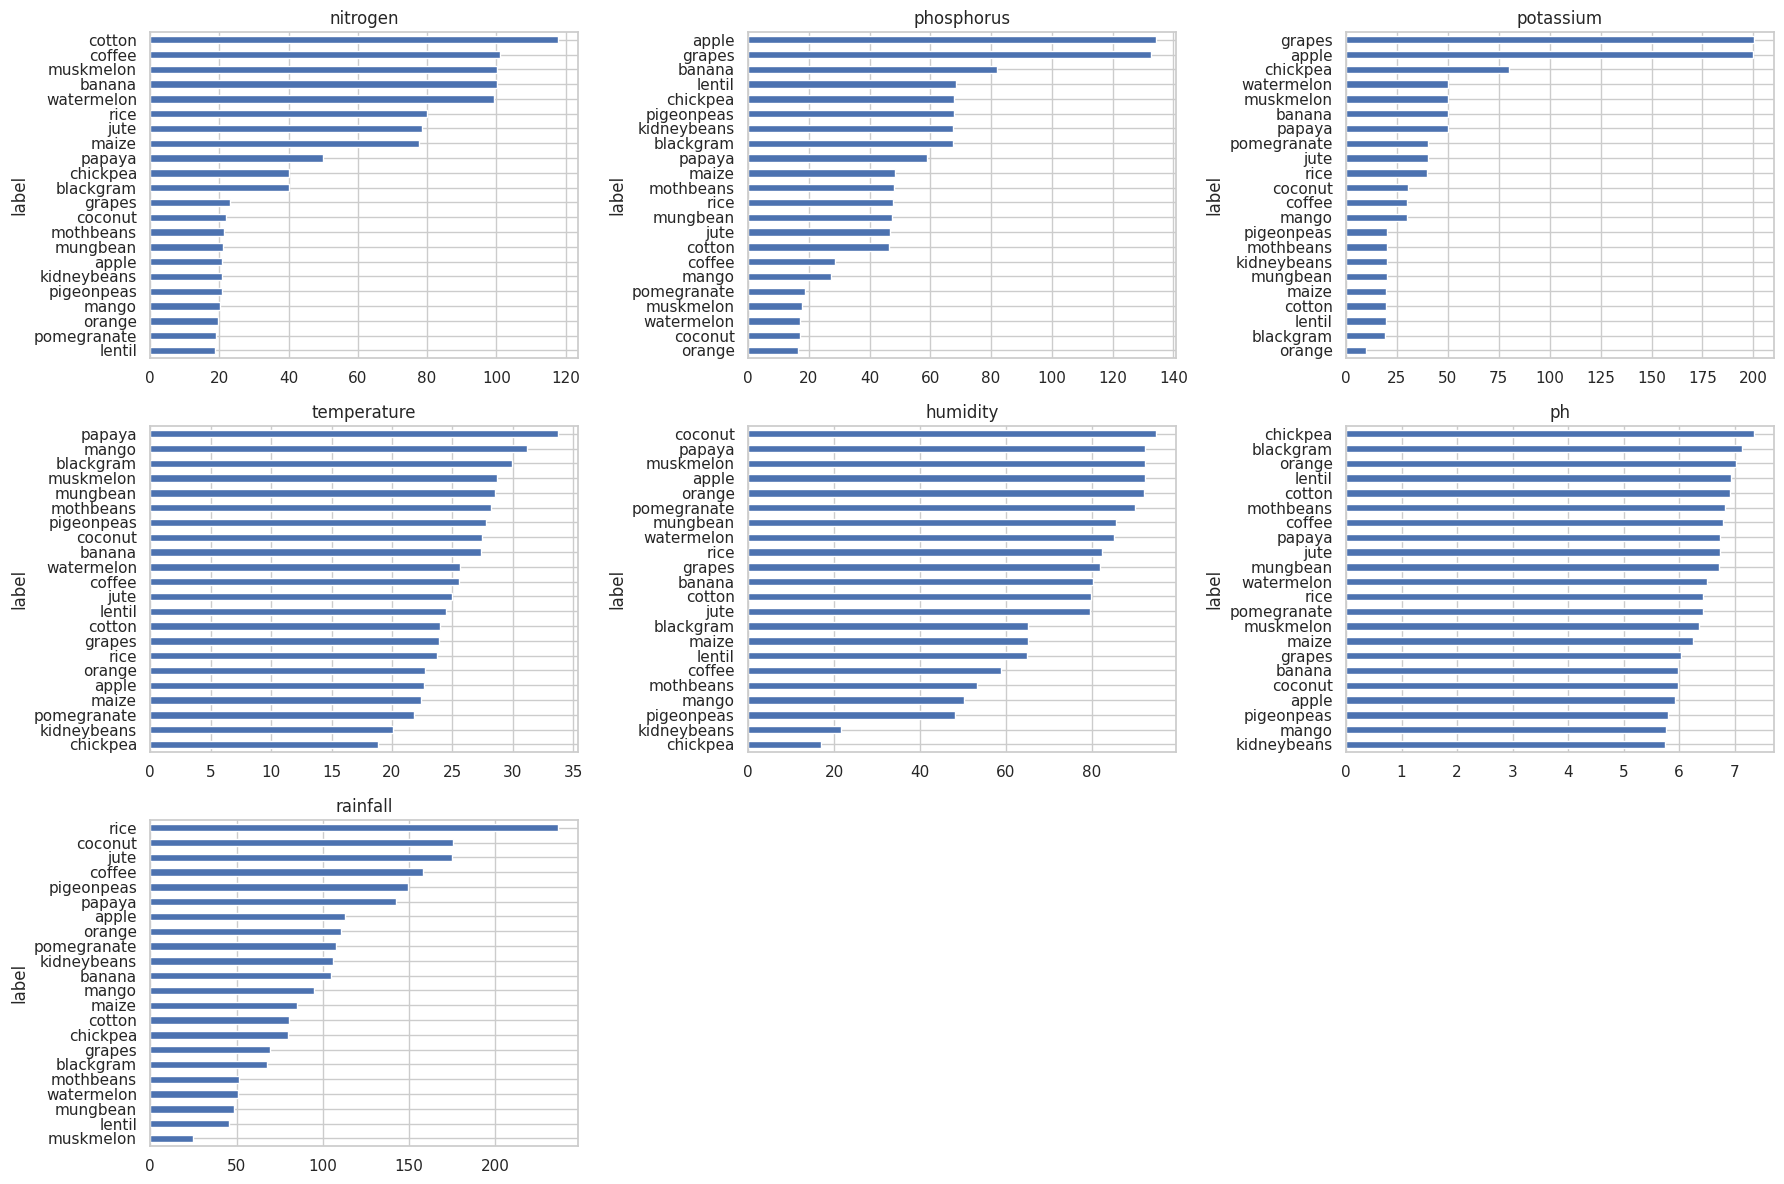

In [ ]:
grouped = df.groupby(TARGET_COLUMN)[FEATURE_COLUMNS].mean().round(2)
display(grouped)

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(FEATURE_COLUMNS):
    grouped[feature].sort_values().plot(kind='barh', ax=axes[i], title=feature)
for i in range(len(FEATURE_COLUMNS), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

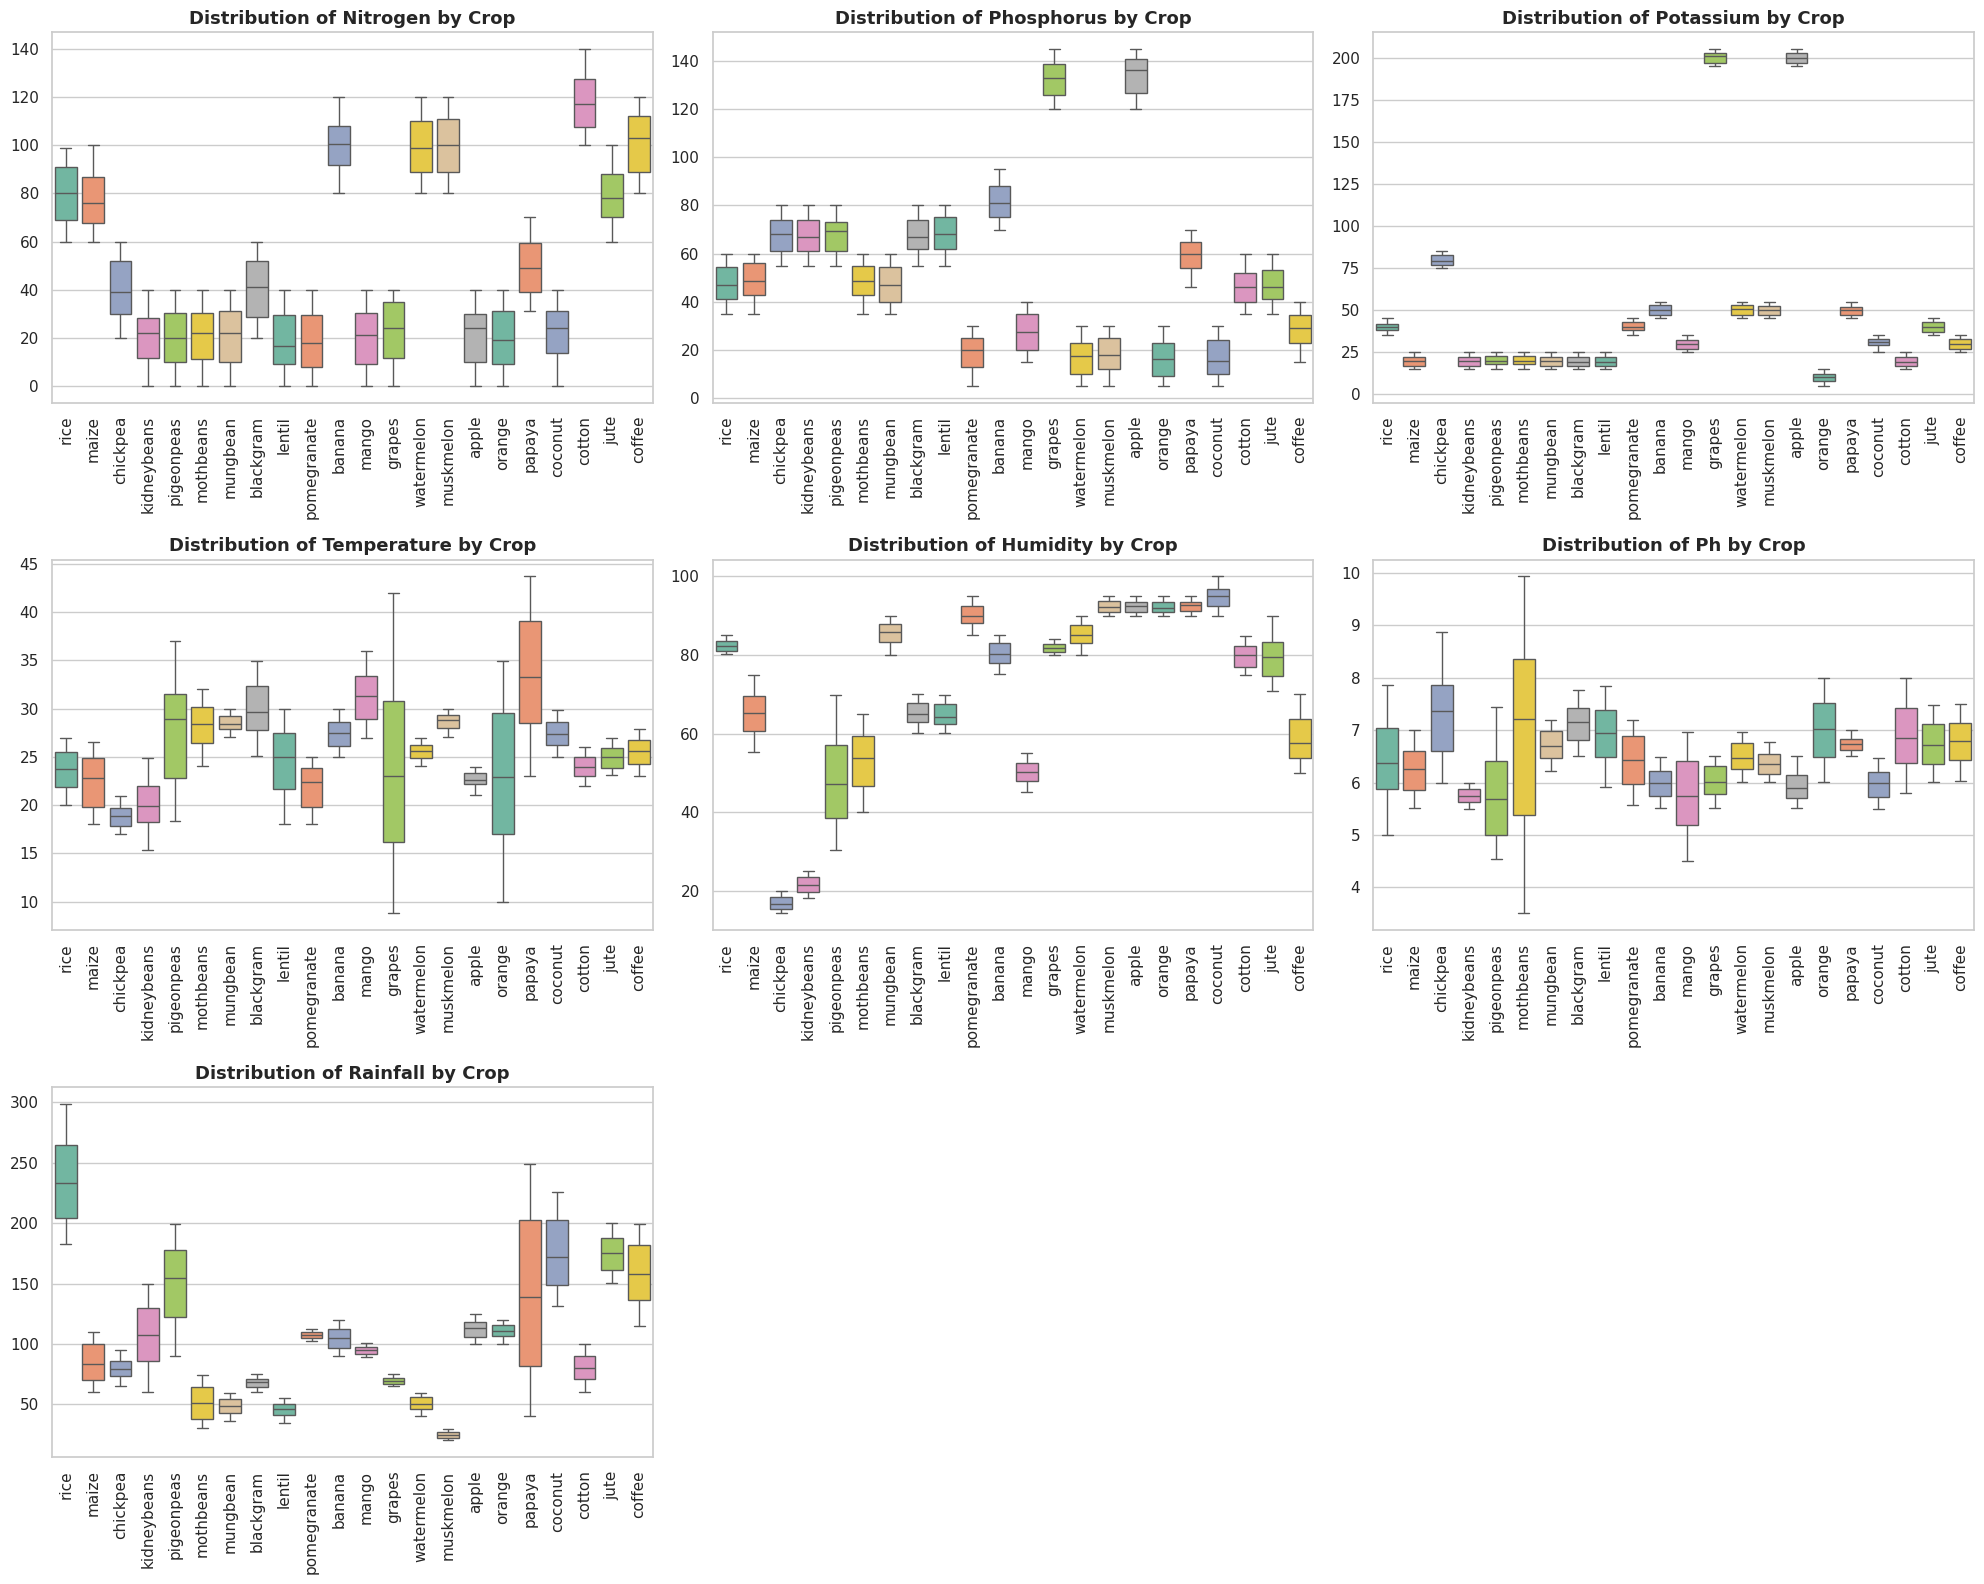

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(FEATURE_COLUMNS):
    sns.boxplot(x=TARGET_COLUMN, y=feature, data=df, ax=axes[i], palette='Set2', hue=TARGET_COLUMN, legend=False)
    axes[i].set_title(f'Distribution of {feature.capitalize()} by Crop', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=90)

for i in range(len(FEATURE_COLUMNS), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

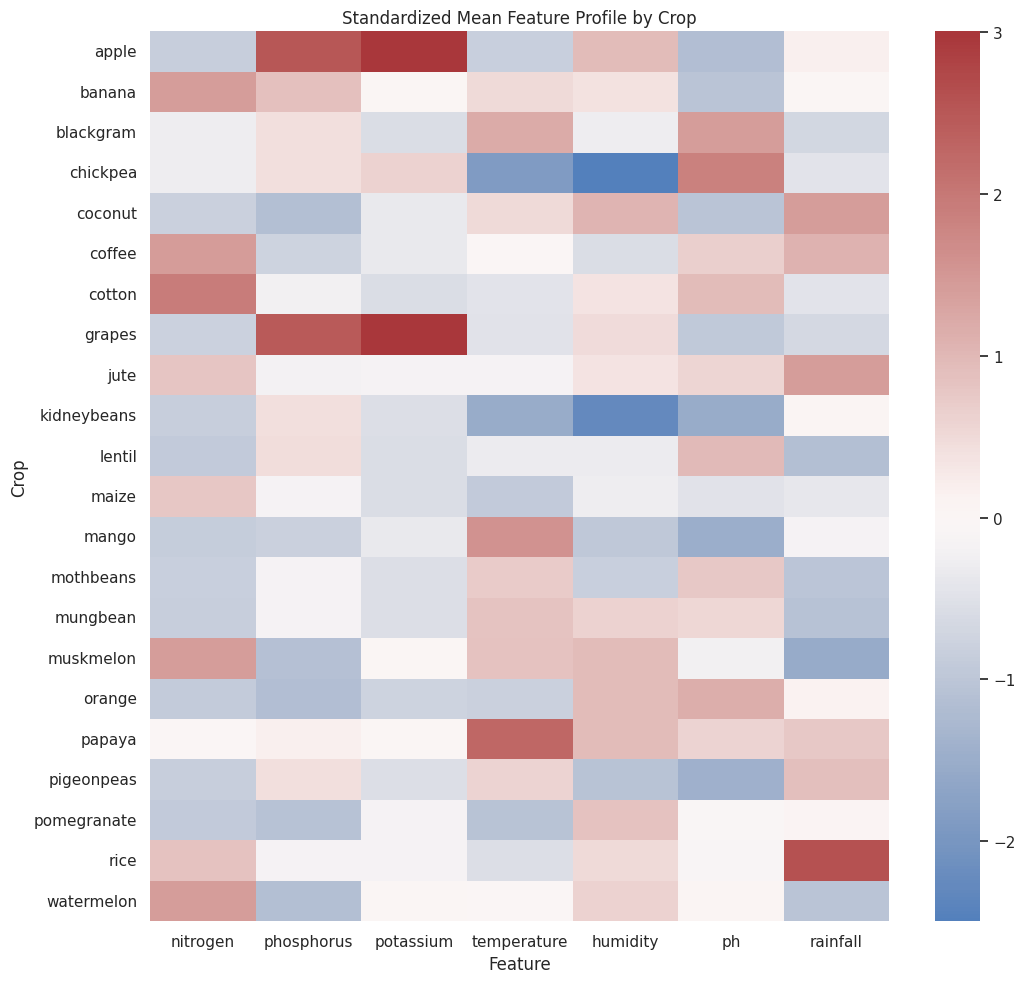

In [ ]:
class_profiles = df.groupby(TARGET_COLUMN)[FEATURE_COLUMNS].mean()
profile_z = (class_profiles - class_profiles.mean()) / class_profiles.std(ddof=0)

plt.figure(figsize=(11, 10))
sns.heatmap(profile_z, cmap="vlag", center=0)
plt.title("Standardized Mean Feature Profile by Crop")
plt.xlabel("Feature")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

### EDA interpretation

- Removing the entirely empty columns prevents meaningless features from entering the model.
- The crop classes are perfectly balanced, so stratified splitting gives every crop a similar representation in train, validation, and test sets.
- Feature ranges differ substantially. Macronutrients and rainfall use very different scales from pH, so distance-based models require scaling.
- Correlated features and class-specific profiles motivate PCA as a diagnostic tool, although the final recommendation models retain all standardized features to preserve information and interpretability.

## 4. Stratified train / validation / test split

The split is performed **before** fitting the imputer, scaler, PCA, KNN model, or K-Means model. This prevents information from validation and test samples from leaking into training.

- Train: 70%
- Validation: 10%
- Test: 20%

In [ ]:
# Perform train/val/test split using split_train_val_test from src/data/split.py
split_data = split_train_val_test(df, target_column=TARGET_COLUMN, random_state=RANDOM_STATE)
X_train, X_val, X_test = split_data.X_train, split_data.X_val, split_data.X_test
y_train, y_val, y_test = split_data.y_train.astype(str), split_data.y_val.astype(str), split_data.y_test.astype(str)

print(
    f"Dataset sizes -> Train: {len(X_train)} ({len(X_train)/len(df):.1%}), "
    f"Val: {len(X_val)} ({len(X_val)/len(df):.1%}), "
    f"Test: {len(X_test)} ({len(X_test)/len(df):.1%})"
)


,split,samples,percentage,classes
0,train,1540,70.0,22
1,validation,220,10.0,22
2,test,440,20.0,22


,train,validation,test
label,,,
apple,70,10,20
banana,70,10,20
blackgram,70,10,20
chickpea,70,10,20
coconut,70,10,20
coffee,70,10,20
cotton,70,10,20
grapes,70,10,20
jute,70,10,20


## 5. Preprocessing: missing values and scaling

1. **Median imputation** is robust to skewed numeric distributions.
2. **Standardization** gives each feature approximately zero mean and unit variance, preventing large-scale features from dominating Euclidean or Manhattan distance.
3. The imputer and scaler are fitted only on the training set during model selection.

In [ ]:
# Fit preprocessor on train and transform splits using functions from src/data/preprocessing.py
imputer, scaler, X_train_scaled = fit_preprocessor(X_train)
X_val_scaled = transform_features(X_val, imputer, scaler)
X_test_scaled = transform_features(X_test, imputer, scaler)

print("Scaling check (training set means and standard deviations):")
summary_scaled = pd.DataFrame(
    {"mean": X_train_scaled.mean(), "std": X_train_scaled.std()}
).round(4)
display(summary_scaled.T)


,feature,train_mean_after_scaling,train_std_after_scaling
0,nitrogen,0.0,1.0
1,phosphorus,0.0,1.0
2,potassium,0.0,1.0
3,temperature,0.0,1.0
4,humidity,-0.0,1.0
5,ph,0.0,1.0
6,rainfall,0.0,1.0


## 6. PCA analysis

PCA is fitted on the scaled training data only. It is used here to:

- estimate how much variance can be summarized with fewer components;
- visualize whether crop classes form separable regions;
- inspect feature contributions to the principal components.

The recommendation models below use the full standardized feature space by default because only seven input features are available and aggressive dimensionality reduction may remove crop-specific information.

,component,explained_variance_ratio,cumulative_variance
0,1,0.2739,0.2739
1,2,0.1876,0.4615
2,3,0.1513,0.6128
3,4,0.1463,0.7591
4,5,0.1155,0.8746
5,6,0.0979,0.9725
6,7,0.0275,1.0000


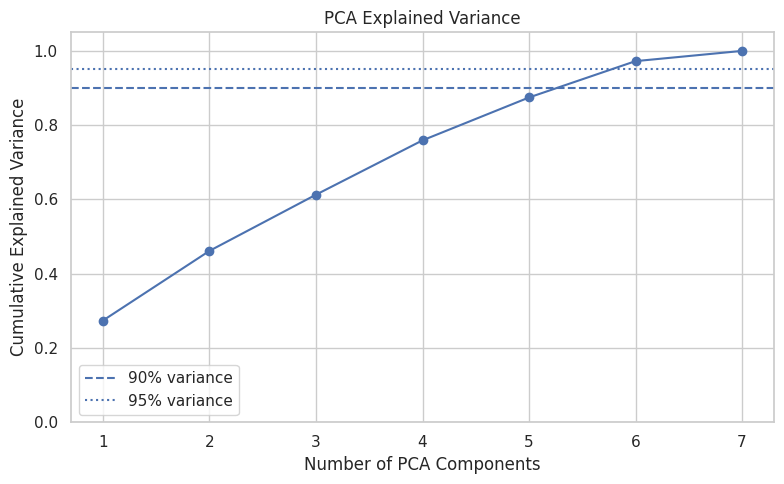

In [ ]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

pca_variance = pd.DataFrame({
    "component": np.arange(1, len(FEATURE_COLUMNS) + 1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_full.explained_variance_ratio_),
})
display(pca_variance.round(4))

plt.figure(figsize=(8, 5))
plt.plot(pca_variance["component"], pca_variance["cumulative_variance"], marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle=":", label="95% variance")
plt.xticks(pca_variance["component"])
plt.ylim(0, 1.05)
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

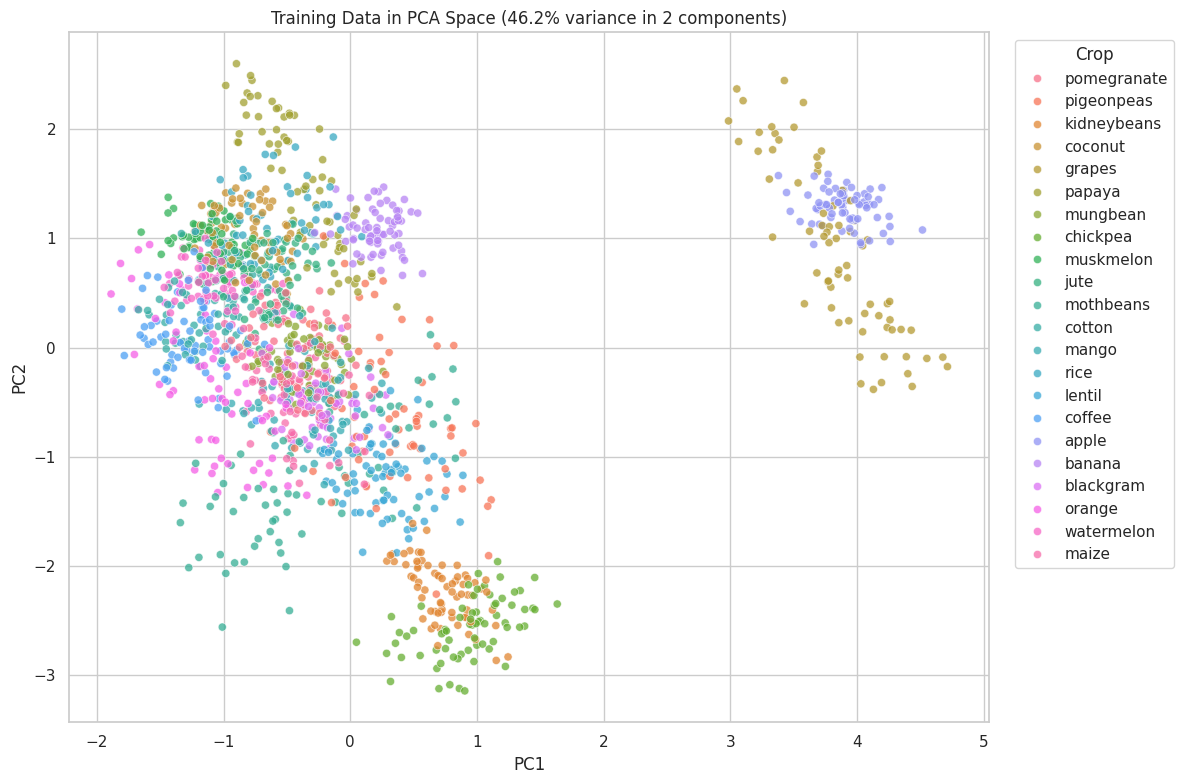

In [ ]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_train_pca2[:, 0],
    "PC2": X_train_pca2[:, 1],
    "crop": y_train.to_numpy(),
})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="crop", s=35, alpha=0.75)
plt.title(
    f"Training Data in PCA Space "
    f"({pca_2d.explained_variance_ratio_.sum():.1%} variance in 2 components)"
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Crop")
plt.tight_layout()
plt.show()

In [ ]:
pca_loadings = pd.DataFrame(
    pca_full.components_.T,
    index=FEATURE_COLUMNS,
    columns=[f"PC{i}" for i in range(1, len(FEATURE_COLUMNS) + 1)],
)
display(pca_loadings.iloc[:, :3].round(3).style.background_gradient(cmap="coolwarm", axis=None))

,PC1,PC2,PC3
nitrogen,-0.308000,0.336000,-0.131000
phosphorus,0.648000,0.032000,-0.098000
potassium,0.625000,0.279000,-0.149000
temperature,-0.175000,0.398000,-0.225000
humidity,-0.068000,0.723000,-0.209000
ph,-0.229000,-0.224000,-0.551000
rainfall,-0.085000,0.277000,0.744000


## 7. Distance functions

For vectors $x$ and $z$:

### Euclidean distance

$$d_{L2}(x,z)=\sqrt{\sum_j(x_j-z_j)^2}$$

The distance between two points in Euclidean space -- the length of the line segment connecting them. Sensitive to large coordinate differences, so scaling is essential. ([read more](https://www.geeksforgeeks.org/maths/euclidean-distance/))

### Manhattan distance (L1)

$$d_{L1}(x,z)=\sum_j|x_j-z_j|$$

Sums the absolute differences of the coordinates -- distance along grid-like paths, like a taxi navigating city streets rather than cutting through buildings. Often more robust when differences are spread across several features.

### Cosine distance

$$d_{cos}(x,z)=1-\frac{x\cdot z}{\|x\|\|z\|}$$

Measures the angle between two vectors rather than their magnitude; a smaller distance indicates higher similarity. The implementation below L2-normalizes vectors before the cosine-distance calculation where relevant (e.g. inside `sklearn`'s `pairwise_distances`).

Below, the three metrics are also implemented from scratch with NumPy (vectorized so a single point can be compared against many points at once), and grouped in a `compute_distance` dispatcher used later by the from-scratch KNN / KNN++ classifiers in the appendix.

In [ ]:
def euclidean_distance(x1, x2):
    """Euclidean (L2) distance between a single point x1 and a point/set of points x2."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    return np.sqrt(np.sum((x2 - x1) ** 2, axis=-1))

d = euclidean_distance(X_train_scaled[0], X_train_scaled[1])
print(f"Euclidean distance between sample 0 and sample 1: {d:.4f}")

Euclidean distance between sample 0 and sample 1: 4.1747


In [ ]:
def manhattan_distance(x1, x2):
    """Manhattan (L1) distance between a single point x1 and a point/set of points x2."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    return np.sum(np.abs(x2 - x1), axis=-1)

d = manhattan_distance(X_train_scaled[0], X_train_scaled[1])
print(f"Manhattan distance between sample 0 and sample 1: {d:.4f}")

Manhattan distance between sample 0 and sample 1: 9.8346


In [ ]:
def cosine_distance(x1, x2, eps=1e-10):
    """Cosine distance = 1 - cosine similarity, between a single point x1 and a point/set of points x2."""
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    dot = np.sum(x2 * x1, axis=-1)
    norm1 = np.linalg.norm(x1)
    norm2 = np.linalg.norm(x2, axis=-1)
    cosine_sim = dot / (norm1 * norm2 + eps)
    return 1 - cosine_sim

d = cosine_distance(X_train_scaled[0], X_train_scaled[1])
print(f"Cosine distance between sample 0 and sample 1: {d:.4f}")

# Group all three functions into one dict shared by the from-scratch KNN / KNN++ models
DISTANCE_FUNCS = {
    "euclidean": euclidean_distance,
    "manhattan": manhattan_distance,
    "cosine": cosine_distance,
}

def compute_distance(x1, x2, metric="euclidean"):
    if metric not in DISTANCE_FUNCS:
        raise ValueError(f"Unsupported metric: {metric}. Choose one of {list(DISTANCE_FUNCS)}")
    return DISTANCE_FUNCS[metric](x1, x2)

Cosine distance between sample 0 and sample 1: 1.6126


**Notes on the implementation:**

- Each function casts inputs to NumPy float arrays and computes along `axis=-1`, so `x2` may be either a single point or a whole matrix of points -- the distance from `x1` to every row of `x2` is computed at once, without an explicit Python loop.
- Cosine distance uses `eps=1e-10` in the denominator purely to avoid division by zero, and converts similarity (closer to 1 = more similar) into a distance (closer to 0 = more similar) so it behaves consistently with the other two metrics.
- `DISTANCE_FUNCS` / `compute_distance(...)` act as a shared dispatcher: passing a metric name as a string switches the formula used, with validation against unsupported metric names. This dispatcher is reused by the from-scratch `CustomKNN` / `KNNPlusPlus` classifiers in the appendix.

## 8. Top-$K$ evaluation metrics

### Precision@K

Measures the proportion of relevant items among the Top-$K$ retrieved results.

$$Precision@K = \frac{\text{Number of relevant items in the Top-K results}}{K}$$

**Worked example:** suppose the system returns the following Top-5 recommendations, out of 8 relevant items in the dataset:

| Rank | Item | Relevant |
|------|------|----------|
| 1 | A | 1 |
| 2 | B | 1 |
| 3 | C | 0 |
| 4 | D | 1 |
| 5 | E | 0 |

There are 3 relevant items in the Top-5 results, so $Precision@5 = 3/5 = 0.6$ -- 60% of the recommended items are relevant. ([read more](https://aiml.com/what-is-precisionk/))

### Recall@K

Measures the proportion of relevant items that are successfully retrieved within the Top-$K$ results.

$$Recall@K = \frac{\text{Number of relevant items in the Top-K results}}{\text{Total number of relevant items}}$$

Using the same example above with 8 relevant items in total, $Recall@5 = 3/8 = 0.375$ -- the system retrieved 37.5% of all relevant items. ([read more](https://www.evidentlyai.com/ranking-metrics/precision-recall-at-k))

### MAP (Mean Average Precision)

Mean of the Average Precision across all queries; related to Precision@K but rewards ranking relevant items earlier. ([read more](https://www.evidentlyai.com/ranking-metrics/mean-average-precision-map))

### Applied to this dataset

Each query in this dataset has exactly **one** relevant crop $y$ and a recommendation list $R_K$, so the general formulas above simplify to:

- **Precision@$K$:** $\frac{|R_K\cap\{y\}|}{K}$
- **Recall@$K$:** $\frac{|R_K\cap\{y\}|}{1}$
- **Hit Rate@$K$:** 1 when $y\in R_K$, otherwise 0
- **Average Precision@$K$:** $1/r$ when the true crop occurs at rank $r\le K$, otherwise 0
- **MAP@$K$:** mean Average Precision across queries
- **NDCG@$K$:** $1/\log_2(r+1)$ when the true crop occurs at rank $r\le K$, otherwise 0

Because there is one relevant label per query, **Recall@$K$ = Hit Rate@$K$**. MAP and NDCG are more informative for ranking quality because they reward placing the correct crop near the top of the list.

In [ ]:
# Ranking metrics function imported from src/evaluation/metrics.py
# ranking_metrics_at_k(y_true, recommendations, k=TOP_K)
print("Using ranking_metrics_at_k from src/evaluation/metrics.py")


## 9. Model 1 - KNN baseline recommender

Instead of returning repeated sample labels, the baseline computes a **class-wise KNN distance score**:

1. Compare a query with every training sample.
2. For each crop, select that crop's nearest `neighbors_per_crop` training samples.
3. Average those distances.
4. Rank crops from smallest average distance to largest.

This produces a unique and interpretable Top-$K$ crop list.

In [ ]:
# Exact KNN recommender imported from src/models/base_knn.py
# CropKNNRecommender
print("Using CropKNNRecommender from src/models/base_knn.py")


## 10. Choosing the number of clusters (silhouette analysis)

Before building the K-Means++ search index, silhouette scores help sanity-check a reasonable range for `n_clusters` on the scaled training data. A higher silhouette score indicates better-separated, more cohesive clusters. This is exploratory: the validation tuning in section 13 still searches over several `n_clusters` values, but this gives a data-driven starting point.

In [ ]:
candidate_clusters = [5, 11, 22, 33, 44]
sil_scores = []
for k in candidate_clusters:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, km.labels_)
    sil_scores.append(score)
    print(f"n_clusters={k:3d} -> silhouette={score:.4f}")

best_n_clusters_silhouette = candidate_clusters[int(np.argmax(sil_scores))]
print(f"\n=> Silhouette-preferred n_clusters = {best_n_clusters_silhouette}")

n_clusters=  5 -> silhouette=0.2838
n_clusters= 11 -> silhouette=0.3504
n_clusters= 22 -> silhouette=0.3500
n_clusters= 33 -> silhouette=0.3199
n_clusters= 44 -> silhouette=0.2995

=> Silhouette-preferred n_clusters = 11


## 11. Model 2 - KNN + K-Means++ search optimizer

K-Means++ is used as a **search index**, not as the final crop predictor:

1. Cluster training samples using K-Means++ initialization.
2. Represent each cluster by its centroid.
3. Rank centroids relative to the query.
4. Search only samples from the nearest cluster(s).
5. Apply the same class-wise KNN crop ranking inside the candidate set.

The search dynamically expands to additional clusters when the current candidate set contains fewer than $K$ distinct crop labels. This guarantees a complete Top-$K$ output while preserving candidate reduction.

In [ ]:
# KMeans search KNN recommender imported from src/models/kmeanSearch_knn.py
# KMeansSearchKNNRecommender
print("Using KMeansSearchKNNRecommender from src/models/kmeanSearch_knn.py")


## 12. Shared evaluation function

The function below evaluates ranking quality and search efficiency. Candidate ratio is the average fraction of training samples examined per query.

In [ ]:
# Evaluation function imported from src/evaluation/evaluate.py
# evaluate_recommender(model, X_eval, y_eval, top_k=TOP_K)
print("Using evaluate_recommender from src/evaluation/evaluate.py")


## 13. Validation tuning - KNN baseline

`neighbors_per_crop` is selected separately for each distance metric using validation MAP@$K$, then NDCG@$K$, then lower latency as tie-breakers.

In [5]:
# Benchmark baseline models using benchmark_baseline_models from src/evaluation/tuning.py
baseline_validation = benchmark_baseline_models(
    X_train_scaled, y_train, X_val_scaled, y_val
)
display(baseline_validation.round(4))


NameError: name 'X_train_scaled' is not defined

In [ ]:
best_baseline_params = (
    baseline_validation
    .groupby("metric", as_index=False)
    .first()[["metric", "neighbors_per_crop", "MAP@K", "NDCG@K"]]
)
print("Selected baseline parameters:")
display(best_baseline_params.round(4))

Selected baseline parameters:


,metric,neighbors_per_crop,MAP@K,NDCG@K
0,cosine,10,0.9750,0.9814
1,euclidean,10,0.9833,0.9877
2,manhattan,10,0.9886,0.9916


## 14. Validation tuning - KNN + K-Means++ optimizer

The K-Means index is fitted once for each `(distance metric, number of clusters)` pair. We then vary:

- number of clusters;
- minimum number of probed clusters;
- neighbors per crop.

Selection prioritizes validation MAP@$K$ and NDCG@$K$, then a smaller candidate ratio and lower latency.

In [ ]:
# Benchmark hybrid models using benchmark_hybrid_models from src/evaluation/tuning.py
hybrid_validation = benchmark_hybrid_models(
    X_train_scaled, y_train, X_val_scaled, y_val
)
print(f"Evaluated {len(hybrid_validation)} hybrid configurations.")
display(hybrid_validation.groupby("metric").head(8).round(4))


Evaluated 108 hybrid configurations.


,model,metric,n_clusters,n_probe,neighbors_per_crop,Precision@K,Recall@K,MAP@K,HitRate@K,NDCG@K,MeanRank_when_hit,Latency_ms_per_query,Avg_candidates,Candidate_ratio,Avg_clusters_scanned
100,KNN + K-Means++,cosine,32,1,3,0.2,1.0,0.9735,1.0,0.9804,1.0591,1.2006,194.0364,0.1260,3.8955
103,KNN + K-Means++,cosine,32,2,3,0.2,1.0,0.9735,1.0,0.9804,1.0591,1.3772,194.0364,0.1260,3.8955
82,KNN + K-Means++,cosine,16,1,3,0.2,1.0,0.9735,1.0,0.9804,1.0591,0.9468,219.9182,0.1428,2.2500
85,KNN + K-Means++,cosine,16,2,3,0.2,1.0,0.9735,1.0,0.9804,1.0591,0.9633,234.5864,0.1523,2.4364
104,KNN + K-Means++,cosine,32,2,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,1.3785,194.0364,0.1260,3.8955
101,KNN + K-Means++,cosine,32,1,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,1.4597,194.0364,0.1260,3.8955
107,KNN + K-Means++,cosine,32,3,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,1.4763,203.1500,0.1319,4.0909
83,KNN + K-Means++,cosine,16,1,5,0.2,1.0,0.9727,1.0,0.9798,1.0636,0.9995,219.9182,0.1428,2.2500
35,KNN + K-Means++,euclidean,32,3,5,0.2,1.0,0.9833,1.0,0.9877,1.0364,1.8076,222.2318,0.1443,4.0364
26,KNN + K-Means++,euclidean,22,3,5,0.2,1.0,0.9833,1.0,0.9877,1.0364,1.8007,245.9682,0.1597,3.2682


In [ ]:
best_hybrid_params = (
    hybrid_validation
    .groupby("metric", as_index=False)
    .first()[[
        "metric", "n_clusters", "n_probe", "neighbors_per_crop",
        "MAP@K", "NDCG@K", "Candidate_ratio"
    ]]
)
print("Selected hybrid parameters:")
display(best_hybrid_params.round(4))

Selected hybrid parameters:


,metric,n_clusters,n_probe,neighbors_per_crop,MAP@K,NDCG@K,Candidate_ratio
0,cosine,32,1,3,0.9735,0.9804,0.1260
1,euclidean,32,3,5,0.9833,0.9877,0.1443
2,manhattan,16,3,3,0.9864,0.9899,0.2162


## 15. Final refit on train + validation, then one-time test evaluation

After hyperparameters are chosen, the preprocessing objects and models are refitted using the combined train and validation sets. The untouched test set is then used once for the final comparison.

In [ ]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_imputer = SimpleImputer(strategy="median")
final_scaler = StandardScaler()

X_trainval_scaled = final_scaler.fit_transform(final_imputer.fit_transform(X_trainval))
X_test_final_scaled = final_scaler.transform(final_imputer.transform(X_test))

final_models = {}
test_rows = []
test_details = {}

for _, params in best_baseline_params.iterrows():
    metric = params["metric"]
    model_name = f"KNN baseline | {metric}"
    model = CropKNNRecommender(
        metric=metric,
        neighbors_per_crop=int(params["neighbors_per_crop"]),
    ).fit(X_trainval_scaled, y_trainval)

    metrics, per_query, recs, diagnostics = evaluate_recommender(
        model, X_test_final_scaled, y_test, top_k=TOP_K
    )
    final_models[model_name] = model
    test_details[model_name] = {
        "per_query": per_query,
        "recommendations": recs,
        "diagnostics": diagnostics,
    }
    test_rows.append({
        "model": "KNN baseline",
        "metric": metric,
        "neighbors_per_crop": int(params["neighbors_per_crop"]),
        "n_clusters": np.nan,
        "n_probe": np.nan,
        **metrics,
    })

for _, params in best_hybrid_params.iterrows():
    metric = params["metric"]
    model_name = f"KNN + K-Means++ | {metric}"
    model = KMeansSearchKNNRecommender(
        metric=metric,
        neighbors_per_crop=int(params["neighbors_per_crop"]),
        n_clusters=int(params["n_clusters"]),
        n_probe=int(params["n_probe"]),
        random_state=RANDOM_STATE,
    ).fit(X_trainval_scaled, y_trainval)

    metrics, per_query, recs, diagnostics = evaluate_recommender(
        model, X_test_final_scaled, y_test, top_k=TOP_K
    )
    final_models[model_name] = model
    test_details[model_name] = {
        "per_query": per_query,
        "recommendations": recs,
        "diagnostics": diagnostics,
    }
    test_rows.append({
        "model": "KNN + K-Means++",
        "metric": metric,
        "neighbors_per_crop": int(params["neighbors_per_crop"]),
        "n_clusters": int(params["n_clusters"]),
        "n_probe": int(params["n_probe"]),
        **metrics,
    })

test_results = pd.DataFrame(test_rows).sort_values(
    ["MAP@K", "NDCG@K", "Candidate_ratio"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(test_results.round(4))

,model,metric,neighbors_per_crop,n_clusters,n_probe,Precision@K,Recall@K,MAP@K,HitRate@K,NDCG@K,MeanRank_when_hit,Latency_ms_per_query,Avg_candidates,Candidate_ratio,Avg_clusters_scanned
0,KNN + K-Means++,manhattan,3,16.0,3.0,0.2,1.0,0.9920,1.0,0.9941,1.0159,0.8636,372.6409,0.2117,3.0045
1,KNN baseline,manhattan,10,NaN,NaN,0.2,1.0,0.9920,1.0,0.9941,1.0159,0.0705,1760.0000,1.0000,NaN
2,KNN + K-Means++,euclidean,5,32.0,3.0,0.2,1.0,0.9905,1.0,0.9930,1.0205,0.8508,240.4773,0.1366,3.9636
3,KNN baseline,euclidean,10,NaN,NaN,0.2,1.0,0.9894,1.0,0.9922,1.0227,0.0824,1760.0000,1.0000,NaN
4,KNN + K-Means++,cosine,3,32.0,1.0,0.2,1.0,0.9784,1.0,0.9841,1.0432,1.4619,221.7341,0.1260,3.9295
5,KNN baseline,cosine,10,NaN,NaN,0.2,1.0,0.9739,1.0,0.9807,1.0523,0.0879,1760.0000,1.0000,NaN


## 16. Comparison of ranking quality and search efficiency

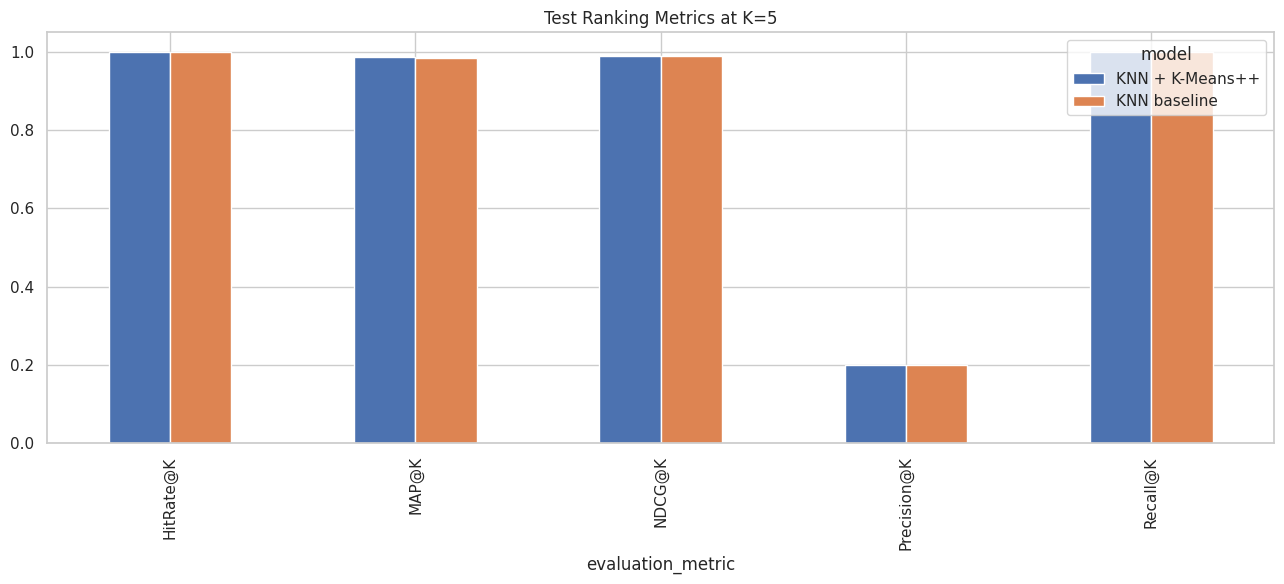

In [ ]:
quality_long = test_results.melt(
    id_vars=["model", "metric"],
    value_vars=["Precision@K", "Recall@K", "MAP@K", "HitRate@K", "NDCG@K"],
    var_name="evaluation_metric",
    value_name="score",
)

plt.figure(figsize=(13, 6))
quality_pivot = quality_long.pivot_table(
    index="evaluation_metric", columns="model", values="score", aggfunc="mean"
)
quality_pivot.plot(kind="bar", ax=plt.gca())
plt.title(f"Test Ranking Metrics at K={TOP_K}")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

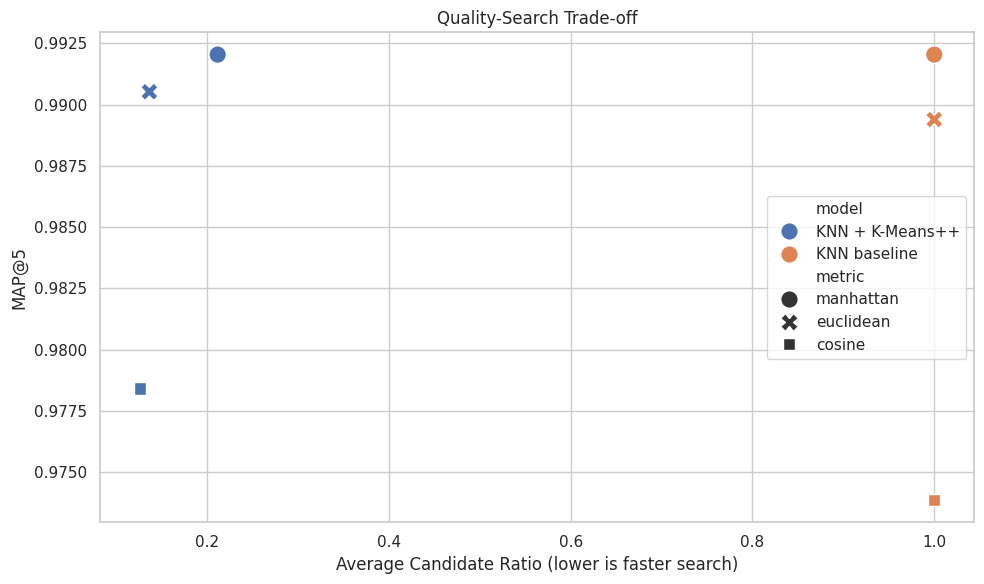

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=test_results,
    x="Candidate_ratio",
    y="MAP@K",
    hue="model",
    style="metric",
    s=160,
)
plt.title("Quality-Search Trade-off")
plt.xlabel("Average Candidate Ratio (lower is faster search)")
plt.ylabel(f"MAP@{TOP_K}")
plt.tight_layout()
plt.show()

In [ ]:
comparison_rows = []
for metric in DISTANCE_METRICS:
    baseline_row = test_results[
        (test_results["model"] == "KNN baseline") &
        (test_results["metric"] == metric)
    ].iloc[0]
    hybrid_row = test_results[
        (test_results["model"] == "KNN + K-Means++") &
        (test_results["metric"] == metric)
    ].iloc[0]

    comparison_rows.append({
        "metric": metric,
        "baseline_MAP@K": baseline_row["MAP@K"],
        "hybrid_MAP@K": hybrid_row["MAP@K"],
        "MAP_delta": hybrid_row["MAP@K"] - baseline_row["MAP@K"],
        "baseline_NDCG@K": baseline_row["NDCG@K"],
        "hybrid_NDCG@K": hybrid_row["NDCG@K"],
        "NDCG_delta": hybrid_row["NDCG@K"] - baseline_row["NDCG@K"],
        "candidate_reduction_pct": (1 - hybrid_row["Candidate_ratio"]) * 100,
        "latency_change_pct": (
            (hybrid_row["Latency_ms_per_query"] / baseline_row["Latency_ms_per_query"] - 1) * 100
        ),
    })

model_comparison = pd.DataFrame(comparison_rows)
display(model_comparison.round(4))

,metric,baseline_MAP@K,hybrid_MAP@K,MAP_delta,baseline_NDCG@K,hybrid_NDCG@K,NDCG_delta,candidate_reduction_pct,latency_change_pct
0,euclidean,0.9894,0.9905,0.0011,0.9922,0.9930,0.0008,86.3365,932.2213
1,manhattan,0.9920,0.9920,0.0000,0.9941,0.9941,0.0000,78.8272,1124.2075
2,cosine,0.9739,0.9784,0.0045,0.9807,0.9841,0.0034,87.4015,1563.8828


### How to interpret the comparison

- A positive `MAP_delta` or `NDCG_delta` means the optimized search improved ranking quality for that distance metric.
- A negative delta indicates a quality cost caused by approximate candidate search.
- `candidate_reduction_pct` directly shows how much of the training set the hybrid avoids scanning on average.
- Actual latency can vary with dataset size and implementation overhead. Candidate reduction becomes more valuable as the training set grows.

### Observed test findings

This cell converts the numerical results into concise, report-ready observations. The exact statements are generated from the current run instead of being hard-coded.

In [ ]:
best_result = test_results.iloc[0]
print(
    f"Best ranking configuration: {best_result['model']} with {best_result['metric']} distance "
    f"(MAP@{TOP_K}={best_result['MAP@K']:.4f}, NDCG@{TOP_K}={best_result['NDCG@K']:.4f})."
)

for _, row in model_comparison.iterrows():
    speed_note = (
        "measured slower on this small dataset because Python-level cluster/candidate handling adds overhead"
        if row["latency_change_pct"] > 0
        else "measured faster in this run"
    )
    print(
        f"- {row['metric'].title()}: K-Means++ reduced the candidate set by "
        f"{row['candidate_reduction_pct']:.1f}%, changed MAP@{TOP_K} by "
        f"{row['MAP_delta']:+.4f}, and was {speed_note}."
    )

print(
    "Candidate reduction demonstrates the search-index effect. Runtime gains are expected to become "
    "more visible with larger datasets or a vectorized/compiled candidate-scoring implementation."
)

Best ranking configuration: KNN + K-Means++ with manhattan distance (MAP@5=0.9920, NDCG@5=0.9941).
- Euclidean: K-Means++ reduced the candidate set by 86.3%, changed MAP@5 by +0.0011, and was measured slower on this small dataset because Python-level cluster/candidate handling adds overhead.
- Manhattan: K-Means++ reduced the candidate set by 78.8%, changed MAP@5 by +0.0000, and was measured slower on this small dataset because Python-level cluster/candidate handling adds overhead.
- Cosine: K-Means++ reduced the candidate set by 87.4%, changed MAP@5 by +0.0045, and was measured slower on this small dataset because Python-level cluster/candidate handling adds overhead.
Candidate reduction demonstrates the search-index effect. Runtime gains are expected to become more visible with larger datasets or a vectorized/compiled candidate-scoring implementation.


## 17. Per-crop performance analysis

Aggregate metrics can hide crops that are difficult to recommend. The following table reports Top-$K$ hit rate and NDCG for every crop using the highest-MAP test configuration.

In [ ]:
best_row = test_results.iloc[0]
best_model_name = f"{best_row['model']} | {best_row['metric']}"
best_detail = test_details[best_model_name]

per_crop = best_detail["per_query"].copy()
per_crop["true_crop"] = y_test.to_numpy()
per_crop_summary = (
    per_crop.groupby("true_crop")
    .agg(
        samples=("HitRate@K", "size"),
        HitRate_at_K=("HitRate@K", "mean"),
        MAP_at_K=("AP@K", "mean"),
        NDCG_at_K=("NDCG@K", "mean"),
        Mean_rank_when_hit=("rank", "mean"),
    )
    .sort_values(["HitRate_at_K", "NDCG_at_K"])
)

print(f"Best test configuration: {best_model_name}")
display(per_crop_summary.round(4))

Best test configuration: KNN + K-Means++ | manhattan


,samples,HitRate_at_K,MAP_at_K,NDCG_at_K,Mean_rank_when_hit
true_crop,,,,,
mothbeans,20,1.0,0.925,0.9446,1.15
maize,20,1.0,0.975,0.9815,1.05
orange,20,1.0,0.975,0.9815,1.05
pigeonpeas,20,1.0,0.975,0.9815,1.05
rice,20,1.0,0.975,0.9815,1.05
apple,20,1.0,1.000,1.0000,1.00
banana,20,1.0,1.000,1.0000,1.00
blackgram,20,1.0,1.000,1.0000,1.00
chickpea,20,1.0,1.000,1.0000,1.00


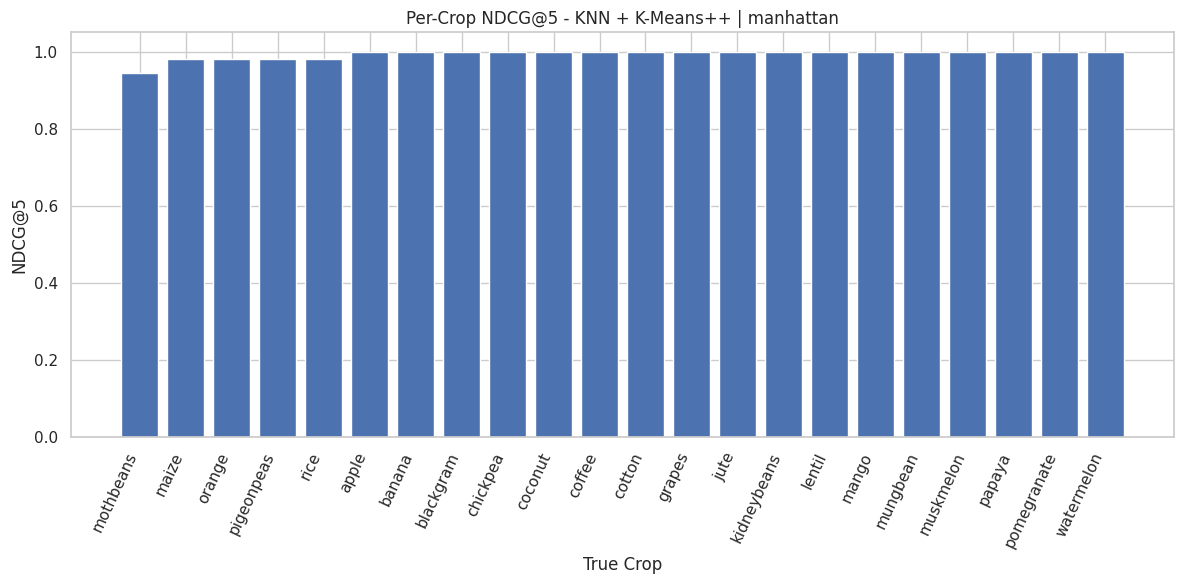

In [ ]:
plt.figure(figsize=(12, 6))
per_crop_plot = per_crop_summary.reset_index()
plt.bar(per_crop_plot["true_crop"], per_crop_plot["NDCG_at_K"])
plt.title(f"Per-Crop NDCG@{TOP_K} - {best_model_name}")
plt.xlabel("True Crop")
plt.ylabel(f"NDCG@{TOP_K}")
plt.xticks(rotation=65, ha="right")
plt.tight_layout()
plt.show()

## 18. Inspect individual recommendations

The table below shows the true crop, ranked recommendations, rank of the true crop, and candidate-search size for test examples.

In [ ]:
best_recs = best_detail["recommendations"]
best_diag = best_detail["diagnostics"]

examples = []
for i in range(min(15, len(X_test))):
    rec_list = list(best_recs[i])
    true_crop = y_test.iloc[i]
    true_rank = rec_list.index(true_crop) + 1 if true_crop in rec_list else None
    examples.append({
        "true_crop": true_crop,
        "recommendations": " > ".join(rec_list),
        "true_rank": true_rank,
        "candidates_examined": int(best_diag["candidate_count"][i]),
        "candidate_ratio": float(best_diag["candidate_ratio"][i]),
    })

display(pd.DataFrame(examples).round(4))

,true_crop,recommendations,true_rank,candidates_examined,candidate_ratio
0,orange,orange > pomegranate > mungbean > coconut > bl...,1,434,0.2466
1,banana,banana > cotton > watermelon > papaya > maize,1,409,0.2324
2,cotton,cotton > maize > watermelon > coffee > banana,1,409,0.2324
3,maize,maize > cotton > pigeonpeas > banana > kidneyb...,1,359,0.2040
4,orange,pomegranate > orange > coconut > maize > cotton,2,402,0.2284
5,chickpea,chickpea > kidneybeans > lentil > pigeonpeas >...,1,294,0.1670
6,rice,rice > papaya > jute > coconut > coffee,1,360,0.2045
7,blackgram,blackgram > lentil > mungbean > mothbeans > maize,1,473,0.2688
8,banana,banana > cotton > maize > watermelon > muskmelon,1,409,0.2324
9,orange,orange > pomegranate > coconut > lentil > moth...,1,348,0.1977


## 19. Reusable prediction function for new feature inputs

The function accepts raw, unscaled feature values and returns the Top-$K$ crops, distances, and normalized compatibility scores.

In [ ]:
def recommend_from_raw_features(
    raw_features,
    model,
    imputer_obj=final_imputer,
    scaler_obj=final_scaler,
    feature_columns=FEATURE_COLUMNS,
    top_k=TOP_K,
):
    """
    raw_features can be:
      - a dictionary with feature names, or
      - a one-row pandas DataFrame.
    """
    recs, diagnostics = recommend_from_raw_features_src(
        raw_features=raw_features,
        model=model,
        imputer=imputer_obj,
        scaler=scaler_obj,
        feature_columns=feature_columns,
        top_k=top_k,
    )

    return pd.DataFrame({
        "rank": np.arange(1, len(recs[0]) + 1),
        "crop": recs[0],
        "distance_score": diagnostics["selected_distances"][0],
        "compatibility": diagnostics["compatibility"][0],
    })


In [ ]:
# Demonstration using the first test sample (features only).
demo_features = X_test.iloc[0].to_dict()
print("Input features:")
display(pd.DataFrame([demo_features]))
print(f"Ground-truth crop: {y_test.iloc[0]}")
print(f"Model: {best_model_name}")

demo_recommendations = recommend_from_raw_features(
    demo_features,
    final_models[best_model_name],
    top_k=TOP_K,
)
display(demo_recommendations.round(4))

Input features:


,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
0,13.0,23.0,6.0,23.961476,90.26408,7.365338,102.69587


Ground-truth crop: orange
Model: KNN + K-Means++ | manhattan


,rank,crop,distance_score,compatibility
0,1,orange,0.9174,0.4365
1,2,pomegranate,1.7260,0.2320
2,3,mungbean,3.1353,0.1277
3,4,coconut,3.6401,0.1100
4,5,blackgram,4.2658,0.0939


## 20. Main conclusions

The final conclusions should be based on the generated `test_results` and `model_comparison` tables rather than assumed in advance.

1. **Scaling is necessary** because KNN and centroid search are distance-based and the raw feature scales differ substantially.
2. **Stratified train/validation/test splitting** preserves all 22 crop classes and prevents optimistic evaluation.
3. **PCA is useful for analysis**, but the final models retain all seven standardized features because dimensionality is already low.
4. **Distance metric selection matters:** Euclidean, Manhattan, and Cosine can rank crop suitability differently.
5. **KNN baseline** provides exact full-data search and serves as the quality reference.
6. **KNN + K-Means++** trades exact search for a smaller candidate set. Its success should be judged jointly by MAP/NDCG, candidate reduction, and latency.
7. With one ground-truth crop per row, **Recall@$K$ and Hit Rate@$K$ are equivalent**, while MAP@$K$ and NDCG@$K$ better distinguish rank positions.

### Recommended reporting format

Use the following evidence in the project report:

- dataset size, number of crop classes, and feature list;
- missing-value and scaling strategy;
- train/validation/test proportions;
- PCA cumulative explained variance;
- selected hyperparameters for each distance metric;
- final test metrics for both models;
- candidate reduction and latency;
- per-crop error analysis and example Top-$K$ outputs.

## 21. Optional export of experiment tables

Run the following cell to save CSV copies of the experiment results for a report or presentation.

In [ ]:
baseline_validation.to_csv("/content/baseline_validation_results.csv", index=False)
hybrid_validation.to_csv("/content/hybrid_validation_results.csv", index=False)
test_results.to_csv("/content/final_test_results.csv", index=False)
model_comparison.to_csv("/content/model_comparison.csv", index=False)
per_crop_summary.to_csv("/content/per_crop_performance.csv")
print("Saved CSV result files to /content/")

Saved CSV result files to /content/


---

## Appendix A: From-scratch KNN / KNN++ classification benchmark (K sweep)

The models above frame the task as **Top-$K$ ranking** (one recommendation list per query). This appendix instead benchmarks the same three distance metrics on a classic **single-label classification** setup: predict one crop per query by majority vote among its $k$ nearest neighbors, evaluated with accuracy / precision / recall / F1, and swept across many values of $k$. It reuses `compute_distance` from section 7 and the scaled train/test splits from section 5.

In [ ]:
class CustomKNN:
    """From-scratch KNN classifier (majority vote), using compute_distance from section 7."""

    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)
        return self

    def _predict_one(self, x):
        dists = compute_distance(x, self.X_train, metric=self.metric)
        k_idx = np.argsort(dists)[:self.k]
        k_labels = self.y_train[k_idx]
        return Counter(k_labels).most_common(1)[0][0]

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X])


def evaluate_model(model, X_test_eval, y_test_eval, name=""):
    start = time.time()
    y_pred = model.predict(X_test_eval)
    predict_time = time.time() - start

    acc = accuracy_score(y_test_eval, y_pred)
    prec = precision_score(y_test_eval, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test_eval, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_eval, y_pred, average='macro', zero_division=0)

    print(f"--- {name} ---")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision (macro) : {prec:.4f}")
    print(f"Recall (macro)    : {rec:.4f}")
    print(f"F1-score (macro)  : {f1:.4f}")
    print(f"Predict time      : {predict_time:.3f}s\n")

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec,
             "f1": f1, "predict_time": predict_time, "y_pred": y_pred}

**Line-by-line notes:**

- `CustomKNN` does not "learn" any parameters -- it simply stores the whole training set for comparison at prediction time (lazy learning). `_predict_one` computes the distance from one query point to all training points at once, takes the indices of the `k` nearest, and predicts the majority label among them.
- `evaluate_model(...)` is a shared helper to evaluate either KNN or KNN++: it times prediction, then reports accuracy, precision, recall, and F1, all averaged `macro` (every crop weighted equally regardless of how many samples it has), returning a dict used for the comparison table further below.

In [ ]:
k_values = [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]
knn_sweep_results = []
knn_results = []
knn_models = {}

for metric in DISTANCE_METRICS:
    for k in k_values:
        knn = CustomKNN(k=k, metric=metric)
        knn.fit(X_train_scaled, y_train)

        start = time.time()
        y_pred = knn.predict(X_test_scaled)
        predict_time = time.time() - start

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        row = {"model": f"KNN ({metric}, k={k})", "metric": metric, "k": k,
               "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
               "predict_time": predict_time, "y_pred": y_pred}
        knn_sweep_results.append(row)

        # Keep the k=5 result so the KNN vs KNN++ comparison below uses a consistent k.
        if k == 5:
            row_k5 = dict(row)
            row_k5["model"] = f"KNN ({metric})"
            knn_results.append(row_k5)
            knn_models[metric] = knn

metric,cosine,euclidean,manhattan
k,,,
5,0.9500,0.9750,0.9864
7,0.9409,0.9773,0.9841
9,0.9477,0.9750,0.9773
11,0.9500,0.9727,0.9818
13,0.9409,0.9727,0.9818
15,0.9432,0.9636,0.9773
17,0.9386,0.9545,0.9750
19,0.9409,0.9455,0.9659
21,0.9295,0.9409,0.9659


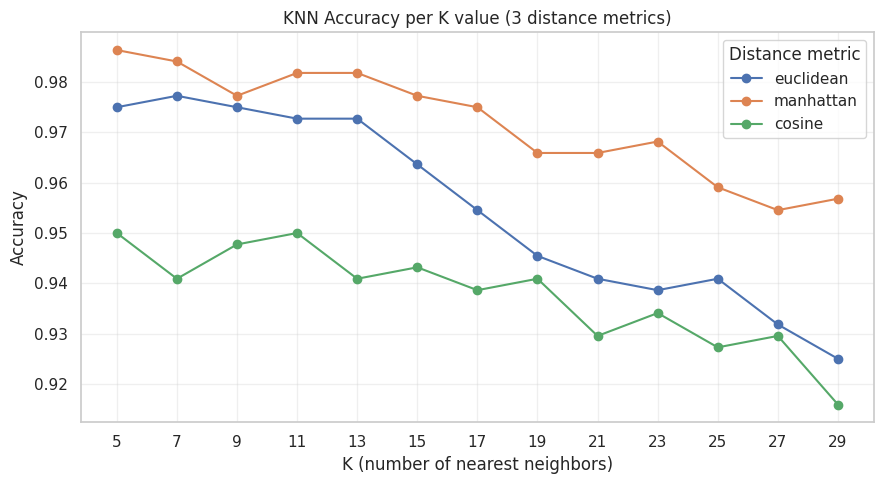

In [ ]:
knn_sweep_df = pd.DataFrame(knn_sweep_results)[["metric", "k", "accuracy", "precision", "recall", "f1", "predict_time"]]

# Table: one row per K, one column per distance metric, values are accuracy
pivot_k = knn_sweep_df.pivot(index="k", columns="metric", values="accuracy")
display(pivot_k.round(4))

plt.figure(figsize=(9, 5))
for metric, color in zip(['euclidean', 'manhattan', 'cosine'], ["#4C72B0", "#DD8452", "#55A868"]):
    subset = knn_sweep_df[knn_sweep_df["metric"] == metric].sort_values("k")
    plt.plot(subset["k"], subset["accuracy"], marker='o', label=metric, color=color)

plt.xlabel("K (number of nearest neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy per K value (3 distance metrics)")
plt.xticks(k_values)
plt.legend(title="Distance metric")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### KNN++ (K-Means-accelerated classification KNN)

Same idea as the K-Means++ search-index recommender in section 11, but for the classification setting: cluster the training data, restrict the neighbor search to the nearest `top_clusters` clusters, and fall back to the full training set if a cluster has fewer points than `k`.

In [ ]:
K = 5  # reference K for the KNN vs KNN++ classification comparison

class KNNPlusPlus:
    def __init__(self, k=5, n_clusters=22, top_clusters=3, metric='euclidean', random_state=42):
        self.k = k
        self.n_clusters = n_clusters
        self.top_clusters = top_clusters
        self.metric = metric
        self.random_state = random_state

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.cluster_labels_ = self.kmeans.fit_predict(self.X_train)
        self.centroids_ = self.kmeans.cluster_centers_
        return self

    def _predict_one(self, x):
        centroid_dists = compute_distance(x, self.centroids_, metric=self.metric)
        nearest_clusters = np.argsort(centroid_dists)[:self.top_clusters]

        mask = np.isin(self.cluster_labels_, nearest_clusters)
        candidates_X = self.X_train[mask]
        candidates_y = self.y_train[mask]

        if len(candidates_X) < self.k:
            candidates_X = self.X_train
            candidates_y = self.y_train

        dists = compute_distance(x, candidates_X, metric=self.metric)
        k_idx = np.argsort(dists)[:self.k]
        k_labels = candidates_y[k_idx]
        return Counter(k_labels).most_common(1)[0][0]

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X])


knnpp_results = []
knnpp_models = {}

for metric in DISTANCE_METRICS:
    knnpp = KNNPlusPlus(k=K, n_clusters=best_n_clusters_silhouette, top_clusters=3, metric=metric)
    knnpp.fit(X_train_scaled, y_train)
    result = evaluate_model(knnpp, X_test_scaled, y_test, name=f"KNN++ ({metric})")
    knnpp_results.append(result)
    knnpp_models[metric] = knnpp

--- KNN++ (euclidean) ---
Accuracy          : 0.9750
Precision (macro) : 0.9768
Recall (macro)    : 0.9750
F1-score (macro)  : 0.9748
Predict time      : 0.100s

--- KNN++ (manhattan) ---
Accuracy          : 0.9864
Precision (macro) : 0.9870
Recall (macro)    : 0.9864
F1-score (macro)  : 0.9862
Predict time      : 0.099s

--- KNN++ (cosine) ---
Accuracy          : 0.9500
Precision (macro) : 0.9558
Recall (macro)    : 0.9500
F1-score (macro)  : 0.9492
Predict time      : 0.147s



In [ ]:
all_results = knn_results + knnpp_results
comparison_df = pd.DataFrame(all_results)[["model", "accuracy", "precision", "recall", "f1", "predict_time"]]
comparison_df["method"] = comparison_df["model"].apply(lambda s: "KNN++" if "++" in s else "KNN")
comparison_df["distance"] = comparison_df["model"].apply(lambda s: s.split('(')[1].strip(')'))
display(comparison_df.sort_values(["distance", "method"]).reset_index(drop=True))

,model,accuracy,precision,recall,f1,predict_time,method,distance
0,KNN (cosine),0.950000,0.955840,0.950000,0.949181,0.062950,KNN,cosine
1,KNN++ (cosine),0.950000,0.955840,0.950000,0.949181,0.146945,KNN++,cosine
2,KNN (euclidean),0.975000,0.976844,0.975000,0.974754,0.046171,KNN,euclidean
3,KNN++ (euclidean),0.975000,0.976844,0.975000,0.974754,0.099669,KNN++,euclidean
4,KNN (manhattan),0.986364,0.987013,0.986364,0.986232,0.040357,KNN,manhattan
5,KNN++ (manhattan),0.986364,0.987013,0.986364,0.986232,0.098913,KNN++,manhattan


---

## Appendix B: Earlier search-index design (sklearn `NearestNeighbors` + single-cluster K-Means)

Before arriving at the `CropKNNRecommender` / `KMeansSearchKNNRecommender` design used in sections 9-11 (class-wise distance averaging, dynamic multi-cluster probing, candidate-ratio tracking), an earlier version of this project used a simpler design built directly on `sklearn.neighbors.NearestNeighbors`: a plain KNN search over the whole training set, and a K-Means-accelerated variant that assigns each query to a single nearest cluster and searches only inside it. It is kept here for reference and traceability.

In [ ]:
class BaseSearchModel:
    def fit(self, X, y):
        pass

    def search(self, X_query):
        pass


class KNNModel(BaseSearchModel):
    """Plain KNN search over the full training set, via sklearn NearestNeighbors."""

    def __init__(self, metric, n_neighbors, **kwargs):
        self.metric = metric
        self.n_neighbors = n_neighbors

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        self.model = NearestNeighbors(metric=self.metric, n_neighbors=self.n_neighbors)
        self.model.fit(X_train)

    def search(self, X_query):
        distances, indices = self.model.kneighbors(X_query)
        return distances, indices


class KMeansKNNModel(BaseSearchModel):
    """KNN restricted to the single nearest K-Means cluster for each query."""

    def __init__(self, metric="euclidean", n_neighbors=5, n_clusters=20, random_state=42):
        self.metric = metric
        self.n_neighbors = n_neighbors
        self.n_clusters = n_clusters
        self.random_state = random_state

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        self.cluster_labels = self.kmeans.fit_predict(X_train)

        self.cluster_to_indices = {}
        self.cluster_knn = {}
        for idx, cluster in enumerate(self.cluster_labels):
            self.cluster_to_indices.setdefault(cluster, []).append(idx)

        for cluster, indices in self.cluster_to_indices.items():
            candidate_vectors = self.X_train[indices]
            knn = NearestNeighbors(
                metric=self.metric,
                n_neighbors=min(self.n_neighbors, len(candidate_vectors))
            )
            knn.fit(candidate_vectors)
            self.cluster_knn[cluster] = knn

    def search(self, X_query):
        all_distances = []
        all_indices = []
        query_clusters = self.kmeans.predict(X_query)

        for query, cluster in zip(X_query, query_clusters):
            query = query.reshape(1, -1)
            candidate_indices = self.cluster_to_indices[cluster]
            knn = self.cluster_knn[cluster]
            distances, local_indices = knn.kneighbors(query)
            global_indices = np.array([candidate_indices[i] for i in local_indices[0]])
            all_distances.append(distances[0])
            all_indices.append(global_indices)

        return np.array(all_distances), np.array(all_indices)

**Why the final design (sections 9-11) supersedes this one:**

- `KMeansKNNModel` probes only the single nearest cluster, which can fail when a query's true crop cluster is close to a cluster boundary. `KMeansSearchKNNRecommender` dynamically expands to more clusters (`n_probe`, plus a distinct-label guarantee) so the Top-$K$ list is always complete.
- Both `KNNModel` and `KMeansKNNModel` return raw nearest-neighbor samples (majority vote / distance order), which can repeat the same crop multiple times in a Top-$K$ list. The final `CropKNNRecommender` instead scores **per crop class** (average distance to each crop's nearest `neighbors_per_crop` samples), guaranteeing a de-duplicated, ranked crop list -- a better fit for a *recommendation* (as opposed to classification) use case.
- The final design also tracks `candidate_ratio` / `clusters_scanned` diagnostics used throughout sections 12-16 for the quality-vs-speed trade-off analysis, which this earlier design does not expose.